In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Lambda, Input, Dense
from tensorflow.keras.models import Model

import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_prominences
import warnings
import time, copy
import pandas as pd

import utils
import TIRE
import simulate
from pathlib import Path
from IPython.display import clear_output
import importlib

In [ ]:
# old settings
window_size = 50
domain = "both" #choose from: TD (time domain), FD (frequency domain) or both

#parameters TD
intermediate_dim_TD=0
latent_dim_TD=2 #h^TD in paper
nr_shared_TD=1 #s^TD in paper
K_TD = 2 #as in paper
nr_ae_TD= K_TD+1 #number of parallel AEs = K+1
loss_weight_TD=1 #lambda_TD in paper

#parameters FD
intermediate_dim_FD=10
latent_dim_FD=2 #h^FD in paper
nr_shared_FD=1 #s^FD in paper
K_FD = 2 #as in paper
nr_ae_FD=K_FD+1 #number of parallel AEs = K+1
loss_weight_FD=1 #lambda^FD in paper
nfft = 30 #number of points for DFT
norm_mode = "timeseries" #for calculation of DFT, should the timeseries have mean zero or each window?

In [24]:
window_size = 50
domain = "both" #choose from: TD (time domain), FD (frequency domain) or both

#parameters TD
intermediate_dim_TD=10
latent_dim_TD=3 #h^TD in paper
nr_shared_TD=2 #s^TD in paper
K_TD = 2 #as in paper
nr_ae_TD= K_TD+1 #number of parallel AEs = K+1
loss_weight_TD=1 #lambda_TD in paper

#parameters FD
intermediate_dim_FD=10
latent_dim_FD=1 #h^FD in paper
nr_shared_FD=1 #s^FD in paper
K_FD = 2 #as in paper
nr_ae_FD=K_FD+1 #number of parallel AEs = K+1
loss_weight_FD=1 #lambda^FD in paper

nfft = 64 #number of points for DFT
norm_mode = "timeseries" #for calculation of DFT, should the timeseries have mean zero or each window?
epochs = 400 

In [25]:
#df = pd.read_csv("D:\gdelt_data\input_datasets\weekly_pw_filtered_features\GBR_COP_data.csv")
#df[df.isna().any(axis=1)]

In [29]:
importlib.reload(TIRE)

all_change_point_scores = {"both": [], "TD": [], "FD": []}
all_dissimilarities = {"both": [], "TD": [], "FD": []}

data_dir = Path(r"../../../data/input_datasets/weekly_pw_filtered_features_modified")
counter = 0
for csv_file in data_dir.glob("*.csv"):

    df = pd.read_csv(csv_file)

    ws_pp = df.copy()

    X = np.column_stack([
        ws_pp['mentions'],
        ws_pp['events'],
        ws_pp['avg_sentenceid'],
        ws_pp['avg_a1co'],
        ws_pp['avg_a2co'],
        ws_pp['avg_actco'],
        ws_pp['avg_raw_text'],
        ws_pp['avg_root_event'],
        ws_pp['avg_len'],
        ws_pp['avg_goldstein'],
        ws_pp['avg_tone'],
        ws_pp['avg_confidence'],
        ws_pp['avg_lat1'],
        ws_pp['avg_lon1'],
        ws_pp['avg_lat2'],
        ws_pp['avg_lon2'],
        ws_pp['avg_lata'],
        ws_pp['avg_lona'],
        ws_pp['total_num_mentions'],
        ws_pp['total_num_sources'],
        ws_pp['total_num_articles'],
    ])

    X = (X - X.mean(axis=0)) / X.std(axis=0)


    # per-channel windows, minmax-scaled per channel, then flattened channel-major via combine_ts
    windows_TD_list = []
    windows_FD_list = []
    for d in range(X.shape[1]):
        w_td = utils.ts_to_windows(X[:, d], 0, window_size, stride=1)
        w_td = utils.minmaxscale(w_td, -1, 1)
        w_fd = utils.calc_fft(w_td, nfft, norm_mode)
        windows_TD_list.append(w_td)
        windows_FD_list.append(w_fd)
    windows_TD = utils.combine_ts(windows_TD_list)
    windows_FD = utils.combine_ts(windows_FD_list)
    #---------------------------#
    ##TRAIN THE AUTOENCODERS
    shared_features_TD = TIRE.train_AE(windows_TD, intermediate_dim_TD, latent_dim_TD, nr_shared_TD, nr_ae_TD, loss_weight_TD, summary=False, verbose=0, nr_epochs=epochs)
    shared_features_FD = TIRE.train_AE(windows_FD, intermediate_dim_FD, latent_dim_FD, nr_shared_FD, nr_ae_FD, loss_weight_FD, summary=False, verbose=0, nr_epochs=epochs)
    #---------------------------#
    ##POSTPROCESSING AND PEAK DETECTION
    for domain in ["both", "TD", "FD"]:
        dissimilarities = TIRE.smoothened_dissimilarity_measures(shared_features_TD, shared_features_FD, domain, window_size)
        change_point_scores = TIRE.change_point_score(dissimilarities, window_size)
        all_change_point_scores[domain].append(change_point_scores)
        all_dissimilarities[domain].append(dissimilarities)

    #clear_output(wait=True)
    print(f"{counter}, processed {csv_file.stem}")

    counter += 1
    #if counter == 10:   
    #    break

14/14 [==============================] - 0s 0s/step
0, processed AFR_GOV_data
14/14 [==============================] - 0s 923us/step
1, processed AFR_USA_data
14/14 [==============================] - 0s 1ms/step
2, processed AFR_ZAF_data
14/14 [==============================] - 0s 942us/step
3, processed AUS_BUS_data
14/14 [==============================] - 0s 1ms/step
4, processed AUS_GOV_data
14/14 [==============================] - 0s 1ms/step
5, processed AUS_USA_data
14/14 [==============================] - 0s 1ms/step
6, processed BUS_AUS_data
14/14 [==============================] - 0s 920us/step
7, processed BUS_CAN_data
14/14 [==============================] - 0s 1ms/step
8, processed BUS_CHN_data
14/14 [==============================] - 0s 729us/step
9, processed BUS_CVL_data
14/14 [==============================] - 0s 1ms/step
10, processed BUS_GBR_data
14/14 [==============================] - 0s 2ms/step
11, processed BUS_GOV_data
14/14 [==============================] - 0s

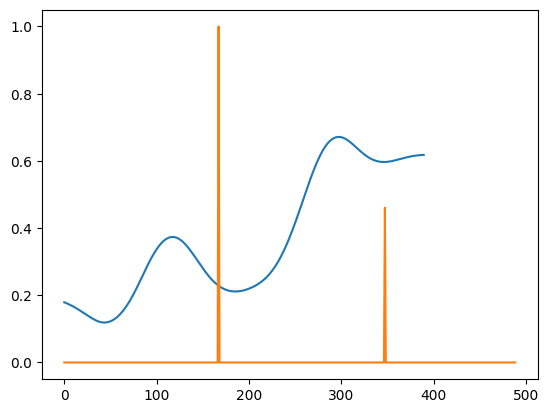

In [12]:
plt.plot(all_dissimilarities["both"][3])
plt.plot(all_change_point_scores["both"][3])

In [28]:
#labels = np.load("D:/gdelt_data/input_datasets/weekly_pw_filtered_features_modified/cp_dict.npy", allow_pickle=True).item()

for number in range(10):
    print(np.flatnonzero(all_change_point_scores["both"][number] > 0))

[ 91 255 351 436]
[]
[ 89 267]
[131 219 332 410]
[]
[]
[ 85 264 377]
[168 295]
[ 88 176 320 435]
[ 53 246 364]


In [17]:
len(all_change_point_scores["both"]), len(all_dissimilarities["both"])

(11, 11)

In [18]:
#np.sum(all_change_point_scores["TD"], axis=0)
for i in range(len(all_change_point_scores["TD"])):
    if np.isnan(np.sum(all_change_point_scores["both"][i])):
        print(i)
    #print(np.sum(all_change_point_scores["both"][i]))

## Save results

In [30]:
#np.save("experiment1_ws50_fs.npy", all_dissimilarities)
#np.save("experiment1_ws50.npy", all_change_point_scores)

np.save("mod_experiment1_ws50_fs.npy", all_dissimilarities)
np.save("mod_experiment1_ws50.npy", all_change_point_scores)

In [97]:
#pd.DataFrame(all_change_point_scores).to_dict(orient="list") == all_change_point_scores #true
#pd.DataFrame(all_change_point_scores).to_csv("experiment0.csv")
#all_change_point_scores = pd.read_csv("experiment0.csv").to_dict(orient="list")
#del all_change_point_scores["Unnamed: 0"]

In [98]:
def parse_array(s):
    s = s.strip()

    # remove surrounding brackets
    s = s[1:-1]

    # parse whitespace-separated numbers
    return np.fromstring(s, sep=' ')

all_change_point_scores = pd.read_csv("experiment0.csv")

all_change_point_scores = {
    col: [parse_array(x) for x in all_change_point_scores[col]]
    for col in all_change_point_scores.columns
    if col != "Unnamed: 0"
}

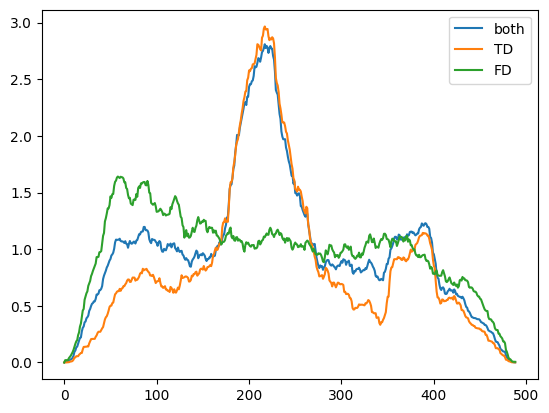

In [99]:
for mode in ["both", "TD", "FD"]:
    scores = np.nansum(all_change_point_scores[mode], axis=0)

    k = 20  # bin size

    window = 50
    smoothed = np.convolve(scores, np.ones(window)/window, mode='same')

    plt.plot(smoothed, label=mode)
plt.legend()
plt.show()

In [100]:
X = np.zeros((489, 21))
# construct a synthetic time series with a change point at index 250
X[200:250, :] = 1
X[:, 0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [ ]:
# per-channel windows, minmax-scaled per channel, then flattened channel-major via combine_ts
windows_TD_list = []
windows_FD_list = []
for d in range(X.shape[1]):
    w_td = utils.ts_to_windows(X[:, d], 0, window_size, stride=1)
    w_td = utils.minmaxscale(w_td, -1, 1)
    w_fd = utils.calc_fft(w_td, nfft, norm_mode)
    windows_TD_list.append(w_td)
    windows_FD_list.append(w_fd)
windows_TD = utils.combine_ts(windows_TD_list)
windows_FD = utils.combine_ts(windows_FD_list)
#---------------------------#
##TRAIN THE AUTOENCODERS
shared_features_TD = TIRE.train_AE(windows_TD, intermediate_dim_TD, latent_dim_TD, nr_shared_TD, nr_ae_TD, loss_weight_TD, summary=False, verbose=0)
shared_features_FD = TIRE.train_AE(windows_FD, intermediate_dim_FD, latent_dim_FD, nr_shared_FD, nr_ae_FD, loss_weight_FD, summary=False, verbose=0)
#---------------------------#
##POSTPROCESSING AND PEAK DETECTION
for domain in ["both", "TD", "FD"]:

    dissimilarities = TIRE.smoothened_dissimilarity_measures(shared_features_TD, shared_features_FD, domain, window_size)print(np.flatnonzero(change_point_scores > 0))

    change_point_scores = TIRE.change_point_score(dissimilarities, window_size)

14/14 [==============================] - 0s 611us/step
[181 269]


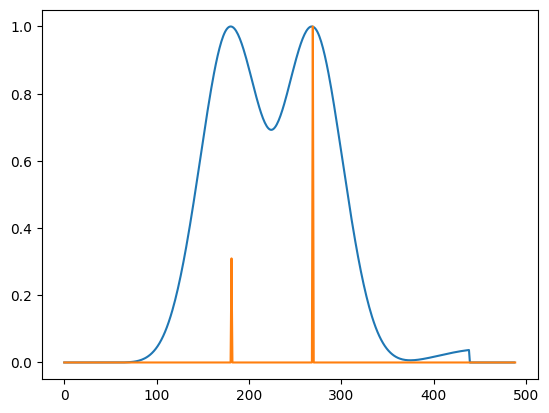

In [102]:
plt.plot(np.pad(dissimilarities / np.max(dissimilarities), (window_size-1, window_size-1), mode='constant'))
plt.plot(change_point_scores)
plt.show()